<a href="https://colab.research.google.com/github/medha327/my_project1/blob/master/deeplablandslide_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf /content/s1s2_landslide_reference_data
!rm -rf /content/seg_dataset

In [ ]:
!wget -O dataset.zip https://zenodo.org/records/17007637/files/s1s2_landslide_reference_data.zip?download=1

--2026-04-29 14:11:06--  https://zenodo.org/records/17007637/files/s1s2_landslide_reference_data.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5991736566 (5.6G) [application/octet-stream]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]   5.58G  22.3MB/s    in 11m 19s 

2026-04-29 14:22:26 (8.42 MB/s) - ‘dataset.zip’ saved [5991736566/5991736566]



In [ ]:
!unzip -oq dataset.zip

In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/s1s2_landslide_reference_data"))

['.config', 'dataset.zip', 's1s2_landslide_reference_data', 'sample_data']
['vector_data', 'original_scenes', 'reference_data', 'README.txt', 'S1S2_dataset.pdf']


In [ ]:
import os

DATASET_ROOT = "/content/s1s2_landslide_reference_data/reference_data"
print(os.listdir(DATASET_ROOT))

['testind_n3_s1s2.h5', 'val_n3_s1s2.h5', 'train_n3_s1s2.h5', 'testspt_n3_s1s2.h5']


In [ ]:
train_h5 = f"{DATASET_ROOT}/train_n3_s1s2.h5"
val_h5   = f"{DATASET_ROOT}/val_n3_s1s2.h5"

In [ ]:
import h5py
import numpy as np
import cv2

OUTPUT_DIR = "/content/seg_dataset"

for split in ["train", "val"]:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/masks/{split}", exist_ok=True)

def process_file(h5_path, split):
    with h5py.File(h5_path, 'r') as f:
        total = len(f["POST1_B04"])

        for i in range(min(400, total)):  # 🔥 more data
            red   = f["POST1_B04"][i][0]
            green = f["POST1_B03"][i][0]
            blue  = f["POST1_B02"][i][0]

            img = np.stack([red, green, blue], axis=-1)
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

            mask = f["None_MASK"][i][0]

            # 🔥 FIX: binary mask
            mask = (mask > 0).astype("uint8")

            name = f"{split}_{i}"

            cv2.imwrite(f"{OUTPUT_DIR}/images/{split}/{name}.png", img)
            cv2.imwrite(f"{OUTPUT_DIR}/masks/{split}/{name}.png", mask * 255)

    print(split, "done")

process_file(train_h5, "train")
process_file(val_h5, "val")

train done
val done


In [ ]:
import torch, cv2, numpy as np
from torch.utils.data import Dataset

class LandslideDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.imgs = os.listdir(img_dir)
        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        name = self.imgs[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        img = cv2.resize(img, (256,256)) / 255.0

        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)
        mask = cv2.resize(mask, (256,256))
        mask = (mask > 0).astype(float)

        # augmentation
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    LandslideDataset(f"{OUTPUT_DIR}/images/train",
                     f"{OUTPUT_DIR}/masks/train"),
    batch_size=8, shuffle=True
)

val_loader = DataLoader(
    LandslideDataset(f"{OUTPUT_DIR}/images/val",
                     f"{OUTPUT_DIR}/masks/val"),
    batch_size=8
)

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def combined_loss(pred, target):
    bce = torch.nn.BCEWithLogitsLoss()(pred, target)
    return bce + dice_loss(pred, target)

criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
from tqdm import tqdm

EPOCHS = 35

train_losses = []
val_losses = []
val_ious = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # -------- TRAIN --------
    model.train()
    total_train = 0

    for imgs, masks in tqdm(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)['out']
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train += loss.item()

    train_loss = total_train / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    total_val = 0
    ious = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)

            total_val += loss.item()

            # IoU
            pred = (torch.sigmoid(outputs) > 0.5).float()
            intersection = (pred * masks).sum()
            union = pred.sum() + masks.sum() - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)

            ious.append(iou.item())

    val_loss = total_val / len(val_loader)
    val_losses.append(val_loss)
    val_ious.append(sum(ious)/len(ious))

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | IoU: {val_ious[-1]:.4f}")


Epoch 1/35


100%|██████████| 45/45 [00:30<00:00,  1.46it/s]


Train Loss: 1.3618 | Val Loss: 1.1157 | IoU: 0.4310

Epoch 2/35


100%|██████████| 45/45 [00:31<00:00,  1.43it/s]


Train Loss: 0.9792 | Val Loss: 0.8839 | IoU: 0.6209

Epoch 3/35


...

Train Loss: 0.1393 | Val Loss: 0.1435 | IoU: 0.8977

Epoch 34/35


100%|██████████| 45/45 [00:35<00:00,  1.27it/s]


Train Loss: 0.1313 | Val Loss: 0.1394 | IoU: 0.9005

Epoch 35/35


100%|██████████| 45/45 [00:35<00:00,  1.27it/s]


Train Loss: 0.1194 | Val Loss: 0.1327 | IoU: 0.9036


In [ ]:
def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

model.eval()
ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)['out']
        iou = iou_score(outputs, masks)
        ious.append(iou.item())

print("Mean IoU:", sum(ious)/len(ious))

Mean IoU: 0.9049339402805675


In [ ]:
import torch

def compute_metrics(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()

    TP = (pred * target).sum()
    TN = ((1 - pred) * (1 - target)).sum()
    FP = (pred * (1 - target)).sum()
    FN = ((1 - pred) * target).sum()

    # Pixel Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)

    # IoU
    intersection = TP
    union = TP + FP + FN
    iou = (intersection + 1e-6) / (union + 1e-6)

    # Precision & Recall
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)

    return accuracy.item(), iou.item(), precision.item(), recall.item()

In [ ]:
def evaluate_model(loader, name="Dataset"):
    model.eval()

    accs, ious, precs, recs = [], [], [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)['out']

            acc, iou, prec, rec = compute_metrics(outputs, masks)

            accs.append(acc)
            ious.append(iou)
            precs.append(prec)
            recs.append(rec)

    print(f"\n{name} Results:")
    print(f"Accuracy : {sum(accs)/len(accs):.4f}")
    print(f"IoU      : {sum(ious)/len(ious):.4f}")
    print(f"Precision: {sum(precs)/len(precs):.4f}")
    print(f"Recall   : {sum(recs)/len(recs):.4f}")

In [ ]:
# TRAIN accuracy
evaluate_model(train_loader, "Train")

# VALIDATION accuracy
evaluate_model(val_loader, "Validation")


Train Results:
Accuracy : 0.9930
IoU      : 0.9368
Precision: 0.9610
Recall   : 0.9734

Validation Results:
Accuracy : 0.9905
IoU      : 0.9035
Precision: 0.9531
Recall   : 0.9445


In [ ]:
testind_h5 = f"{DATASET_ROOT}/testind_n3_s1s2.h5"
testspt_h5 = f"{DATASET_ROOT}/testspt_n3_s1s2.h5"

In [ ]:
for split in ["train", "val", "testind", "testspt"]:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/masks/{split}", exist_ok=True)

In [ ]:
process_file(train_h5, "train")
process_file(val_h5, "val")
process_file(testind_h5, "testind")   # ✅ NEW
process_file(testspt_h5, "testspt")   # ✅ NEW

train done
val done
testind done
testspt done


In [ ]:
from torch.utils.data import DataLoader

testind_loader = DataLoader(
    LandslideDataset(f"{OUTPUT_DIR}/images/testind",
                     f"{OUTPUT_DIR}/masks/testind"),
    batch_size=8
)

testspt_loader = DataLoader(
    LandslideDataset(f"{OUTPUT_DIR}/images/testspt",
                     f"{OUTPUT_DIR}/masks/testspt"),
    batch_size=8
)

In [ ]:
evaluate_model(testind_loader, "Test Independent")
evaluate_model(testspt_loader, "Test Spatial")


Test Independent Results:
Accuracy : 0.9368
IoU      : 0.4678
Precision: 0.9462
Recall   : 0.4734

Test Spatial Results:
Accuracy : 0.8939
IoU      : 0.3020
Precision: 0.6841
Recall   : 0.3499


In [ ]:
import torch

def show_accuracy(loader, name="Dataset"):
    model.eval()

    total_acc = 0
    total_iou = 0
    total_prec = 0
    total_rec = 0
    count = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)['out']
            pred = (torch.sigmoid(outputs) > 0.5).float()

            TP = (pred * masks).sum()
            TN = ((1 - pred) * (1 - masks)).sum()
            FP = (pred * (1 - masks)).sum()
            FN = ((1 - pred) * masks).sum()

            acc = (TP + TN) / (TP + TN + FP + FN + 1e-6)
            iou = TP / (TP + FP + FN + 1e-6)
            prec = TP / (TP + FP + 1e-6)
            rec = TP / (TP + FN + 1e-6)

            total_acc += acc.item()
            total_iou += iou.item()
            total_prec += prec.item()
            total_rec += rec.item()
            count += 1

    print(f"\n📊 {name} Performance:")
    print(f"Accuracy  : {total_acc/count:.4f}")
    print(f"IoU       : {total_iou/count:.4f}")
    print(f"Precision : {total_prec/count:.4f}")
    print(f"Recall    : {total_rec/count:.4f}")

In [ ]:
show_accuracy(train_loader, "Train")
show_accuracy(val_loader, "Validation")

# if test exists
show_accuracy(testind_loader, "Test Independent")
show_accuracy(testspt_loader, "Test Spatial")


📊 Train Performance:
Accuracy  : 0.9931
IoU       : 0.9399
Precision : 0.9634
Recall    : 0.9745

📊 Validation Performance:
Accuracy  : 0.9908
IoU       : 0.9067
Precision : 0.9527
Recall    : 0.9484

📊 Test Independent Performance:
Accuracy  : 0.9349
IoU       : 0.4608
Precision : 0.9307
Recall    : 0.4690

📊 Test Spatial Performance:
Accuracy  : 0.8945
IoU       : 0.3098
Precision : 0.6824
Recall    : 0.3594


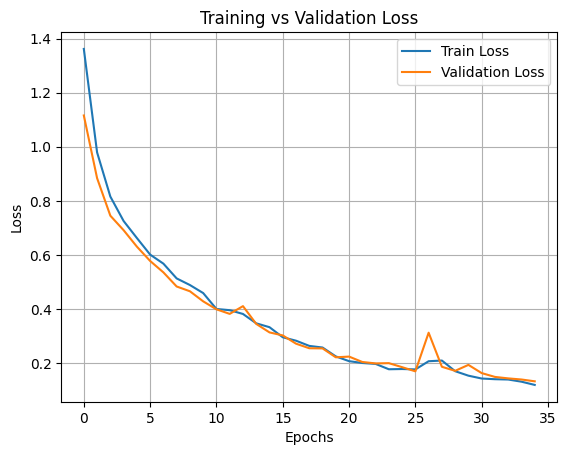

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

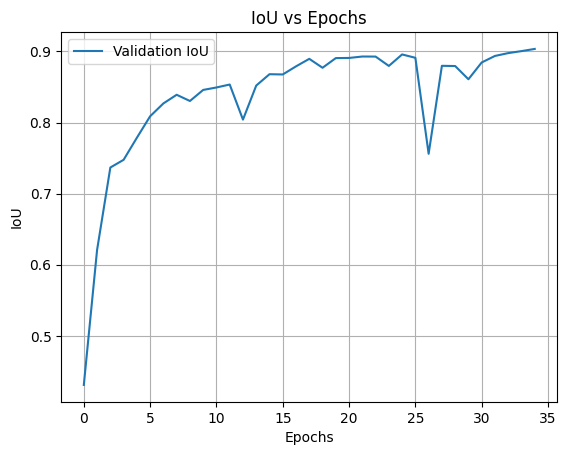

In [ ]:
plt.figure()
plt.plot(val_ious, label="Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("IoU vs Epochs")
plt.legend()
plt.grid()
plt.show()

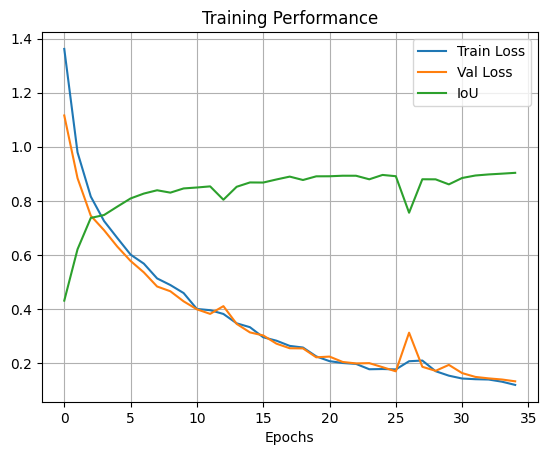

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.plot(val_ious, label="IoU")
plt.xlabel("Epochs")
plt.title("Training Performance")
plt.legend()
plt.grid()
plt.show()

In [ ]:
precisions = []
recalls = []

model.eval()

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)['out']
        pred = (torch.sigmoid(outputs) > 0.5).float()

        TP = (pred * masks).sum()
        FP = (pred * (1 - masks)).sum()
        FN = ((1 - pred) * masks).sum()

        precision = TP / (TP + FP + 1e-6)
        recall = TP / (TP + FN + 1e-6)

        precisions.append(precision.item())
        recalls.append(recall.item())

print("Precision:", sum(precisions)/len(precisions))
print("Recall:", sum(recalls)/len(recalls))

Precision: 0.9518534541130066
Recall: 0.946777034889568


In [ ]:
plt.savefig("loss_graph.png")

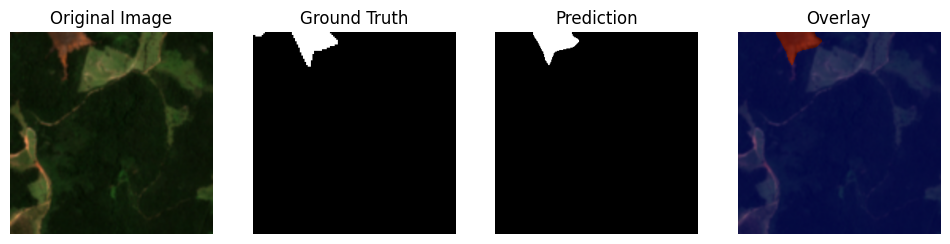

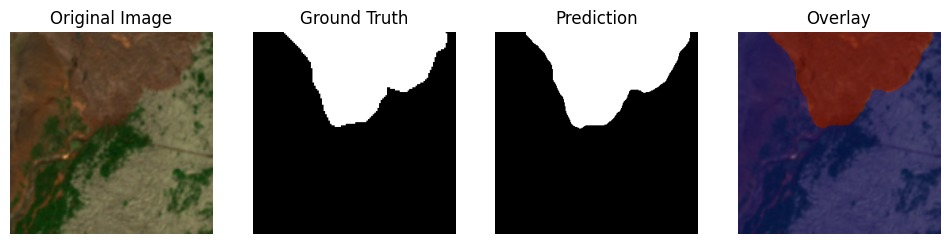

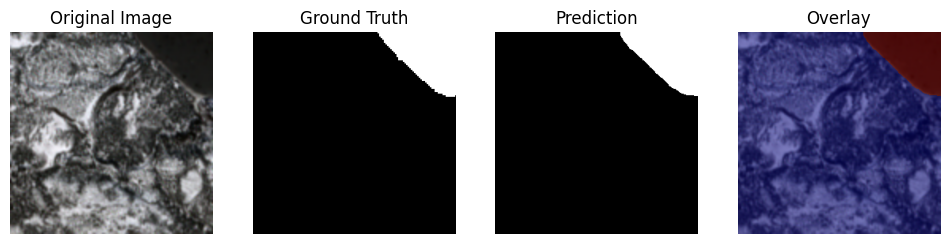

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

# Get one batch
imgs, masks = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)['out']

# Convert predictions
preds = torch.sigmoid(outputs)
preds = (preds > 0.5).float().cpu()

imgs = imgs.cpu()
masks = masks.cpu()

# Show 3 samples
for i in range(3):
    plt.figure(figsize=(12,4))

    # 🔹 Original Image
    plt.subplot(1,4,1)
    img = imgs[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # 🔹 Ground Truth
    plt.subplot(1,4,2)
    plt.imshow(masks[i][0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    # 🔹 Prediction
    plt.subplot(1,4,3)
    plt.imshow(preds[i][0], cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    # 🔹 Overlay (BEST VISUAL)
    plt.subplot(1,4,4)
    plt.imshow(img)
    plt.imshow(preds[i][0], cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

In [ ]:
import numpy as np

def normalize_confusion_matrix(TP, TN, FP, FN):
    cm = np.array([[TN, FP],
                   [FN, TP]], dtype=float)

    # normalize row-wise
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = cm / (row_sums + 1e-6)

    return cm_norm

cm_norm = normalize_confusion_matrix(TP, TN, FP, FN)

print("Normalized Confusion Matrix:\n", cm_norm)

NameError: name 'TP' is not defined

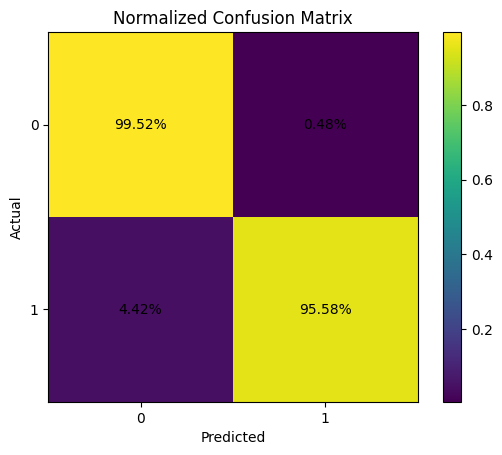

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm_norm)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

labels = ["0", "1"]

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_norm[i][j]*100:.2f}%",
                 ha='center', va='center')

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

plt.colorbar()
plt.show()

In [ ]:
def compute_f1(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()

    TP = (pred * target).sum()
    FP = (pred * (1 - target)).sum()
    FN = ((1 - pred) * target).sum()

    f1 = (2 * TP) / (2 * TP + FP + FN + 1e-6)
    return f1.item()

In [ ]:
f1s = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)['out']
        f1 = compute_f1(outputs, masks)

        f1s.append(f1)

print("Mean F1:", sum(f1s)/len(f1s))

Mean F1: 0.9486148682507601


In [ ]:
def compute_precision_recall(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()

    TP = (pred * target).sum()
    FP = (pred * (1 - target)).sum()
    FN = ((1 - pred) * target).sum()

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)

    return precision.item(), recall.item()

In [ ]:
precisions = []
recalls = []

model.eval()

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)['out']

        p, r = compute_precision_recall(outputs, masks)

        precisions.append(p)
        recalls.append(r)

print("Mean Precision:", sum(precisions)/len(precisions))
print("Mean Recall   :", sum(recalls)/len(recalls))

Mean Precision: 0.9528004201975736
Mean Recall   : 0.9478886506774209


In [ ]:
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Dropout) or isinstance(module, torch.nn.Dropout2d):
        print(f"{name} -> {module}")

classifier.0.project.3 -> Dropout(p=0.5, inplace=False)
aux_classifier.3 -> Dropout(p=0.1, inplace=False)


In [ ]:
for module in model.modules():
    if isinstance(module, torch.nn.Dropout) or isinstance(module, torch.nn.Dropout2d):
        print("Dropout probability:", module.p)

Dropout probability: 0.5
Dropout probability: 0.1


In [ ]:
from torchvision.models.segmentation import deeplabv3_resnet50

In [ ]:
print("Model mode:", "Train" if model.training else "Eval")

Model mode: Eval


In [ ]:
print(model.classifier)

DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_